✅ Libraries loaded successfully!
✅ Dataset loaded!
   Shape : 891 rows × 15 columns

── First 5 rows ──
═══════════════════════════════════════
  DATASET INFO
═══════════════════════════════════════
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alo

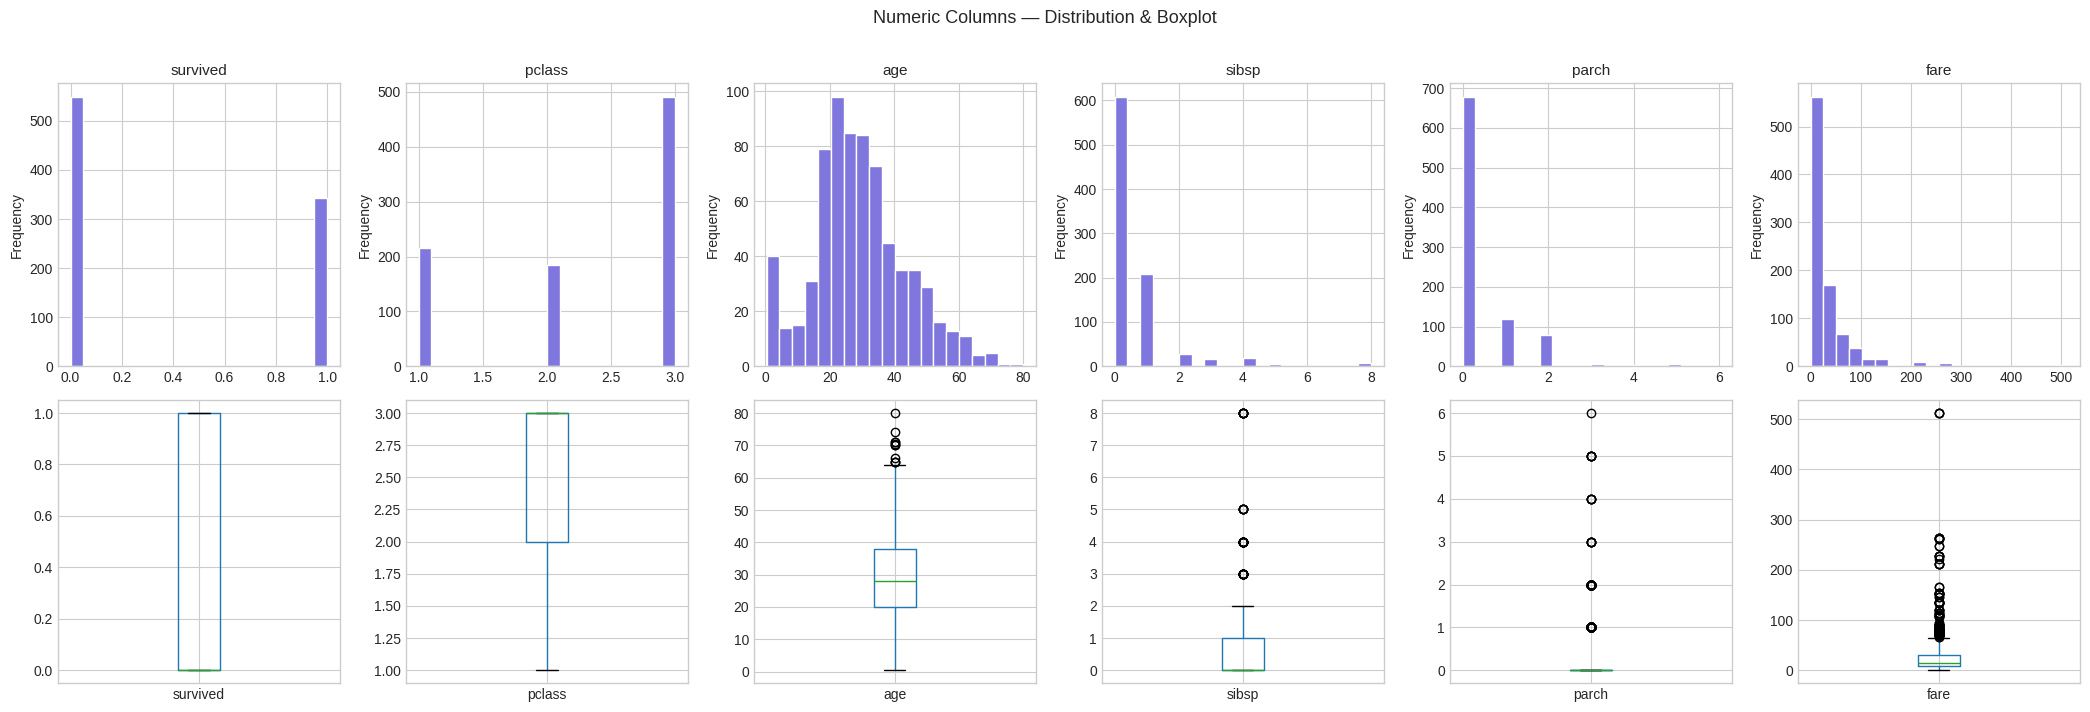


✅ EDA complete! You now understand your dataset's structure.


In [1]:
# ── Cell 1: Install & Import Libraries ──────────────────────────────────────
# pandas: data manipulation | seaborn: built-in datasets | matplotlib: plotting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make plots look cleaner
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Libraries loaded successfully!")


# ── Cell 2: Load the Dataset ─────────────────────────────────────────────────
# Using the Titanic dataset (built into seaborn — no file upload needed!)
# To use YOUR OWN CSV instead, replace this with:
#   df = pd.read_csv("your_file.csv")

df = sns.load_dataset('titanic')

print(f"✅ Dataset loaded!")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns\n")

# Preview first 5 rows
print("── First 5 rows ──")
df.head()


# ── Cell 3: Understand Structure & Data Types ────────────────────────────────

# 3a. Column names, data types, and non-null counts
print("═══════════════════════════════════════")
print("  DATASET INFO")
print("═══════════════════════════════════════")
df.info()

# 3b. Count of each data type
print("\n── Data Type Summary ──")
print(df.dtypes.value_counts())

# 3c. Missing values per column
print("\n── Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

# 3d. Unique values per column (helps identify categorical columns)
print("\n── Unique Values Per Column ──")
for col in df.columns:
    n = df[col].nunique()
    dtype = df[col].dtype
    print(f"  {col:<20} {str(dtype):<12} {n} unique values")


# ── Cell 4: Descriptive Statistics & Visualizations ──────────────────────────

# 4a. Summary statistics for numeric columns
print("═══════════════════════════════════════")
print("  DESCRIPTIVE STATISTICS")
print("═══════════════════════════════════════")
print(df.describe().round(2))

# 4b. Categorical columns — value counts
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
print(f"\n── Categorical Columns: {list(cat_cols)} ──")
for col in cat_cols[:4]:  # show first 4 to keep output clean
    print(f"\n  [{col}]")
    print(df[col].value_counts())

# 4c. Visualizations
num_cols = df.select_dtypes(include='number').columns.tolist()
n = len(num_cols)

fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))
fig.suptitle("Numeric Columns — Distribution & Boxplot", fontsize=13, y=1.01)

for i, col in enumerate(num_cols):
    # Histogram
    df[col].dropna().plot(kind='hist', ax=axes[0, i], bins=20,
                          color='#7F77DD', edgecolor='white')
    axes[0, i].set_title(col, fontsize=11)
    axes[0, i].set_xlabel('')
    # Boxplot
    df[[col]].dropna().boxplot(ax=axes[1, i])

plt.tight_layout()
plt.show()
print("\n✅ EDA complete! You now understand your dataset's structure.")